<table style="background-color:#F5F5F5;" width="100%">
<tr><td style="background-color:#F5F5F5;"><img src="../images/logo.png" width="150" align='right'/></td></tr>     <tr><td>
            <h2><center>Machine Learning in Biomedical Engineering</center></h2>
            <h3><center>1st Semester - 2025/2026</center></h3>
            <h4><center>Universidade Nova de Lisboa - Faculdade de Ciências e Tecnologia</center></h4>
</td></tr>
    <tr><td><h2><b><center>Project: Heartbeat Classification</center></b></h2>
    <h4><i><b><center>Trabalho Realizado por: Guilherme Antunes nº65484 e José Miranda nº75207</center></b></i></h4></td></tr>
</table>

The dataset used in this project is the ECG Heartbeat Categorization Dataset from Kaggle.
It contains heartbeats extracted from two datasets: the **MIT-BIH Arrhythmia Database** and the **PTB Diagnostic ECG Database**.
Each row in the CSV file corresponds to a heartbeat, consisting of 188 samples.


## DATA PREPARATION

In [3]:
import pandas as pd
#leitura dos ficheiros CSV
train_df = pd.read_csv("/Users/mirandaaa/Desktop/Fct- UNI/4º Ano/AAEB/Projeto/Dataset/mitbih_train.csv", header=None)
test_df = pd.read_csv("/Users/mirandaaa/Desktop/Fct- UNI/4º Ano/AAEB/Projeto/Dataset/mitbih_test.csv", header=None)

#verificação das dimensões
print("Dimensões do conjunto de treino:", train_df.shape)
print("Dimensões do conjunto de teste:", test_df.shape)

train_df.head()

Dimensões do conjunto de treino: (87554, 188)
Dimensões do conjunto de teste: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Each row is a signal of 187 samples that describes the complete shape of a single heartbeat, where column 187 is the target:

* Each row: individual heartbeat

* Each column (0–186): signal value at the corresponding time

* Last column: heartbeat class

Tipos de dados:
0    float64
1    float64
2    float64
3    float64
4    float64
dtype: object

 Total de valores em falta: 0


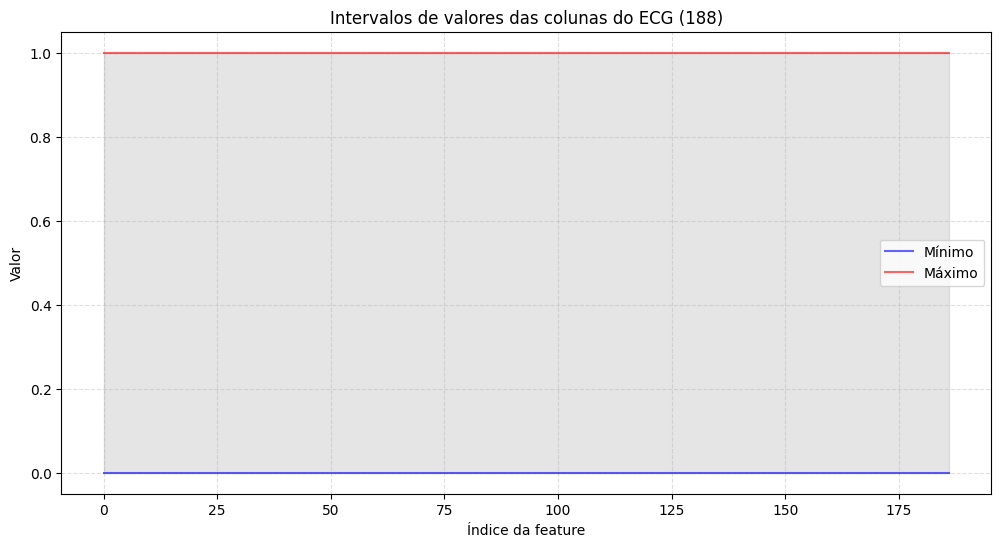

In [4]:
#verificações dos tipos de dados, features dentro de valores coerentes e verificar se a distribuição de classes está equilibrada
import matplotlib.pyplot as plt

print("Tipos de dados:")
print(train_df.dtypes.head())

#verificar se há valores em falta
missing_counts = train_df.isna().sum()
print("\n Total de valores em falta:", missing_counts.sum())

#Intervalos de valores das features
min_vals = train_df.iloc[:, :-1].min()
max_vals = train_df.iloc[:, :-1].max()

plt.figure(figsize=(12, 6))
plt.plot(range(len(min_vals)), min_vals, label='Mínimo', color='blue', alpha=0.6)
plt.plot(range(len(max_vals)), max_vals, label='Máximo', color='red', alpha=0.6)
plt.fill_between(range(len(min_vals)), min_vals, max_vals, color='gray', alpha=0.2)
plt.title('Intervalos de valores das colunas do ECG (188)')
plt.xlabel('Índice da feature')
plt.ylabel('Valor')
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

#os dados já estão normalizados entre 0 e 1
#confirmando isto creio que já não é necessário aplicar o StandardScaler para normalizar os valores

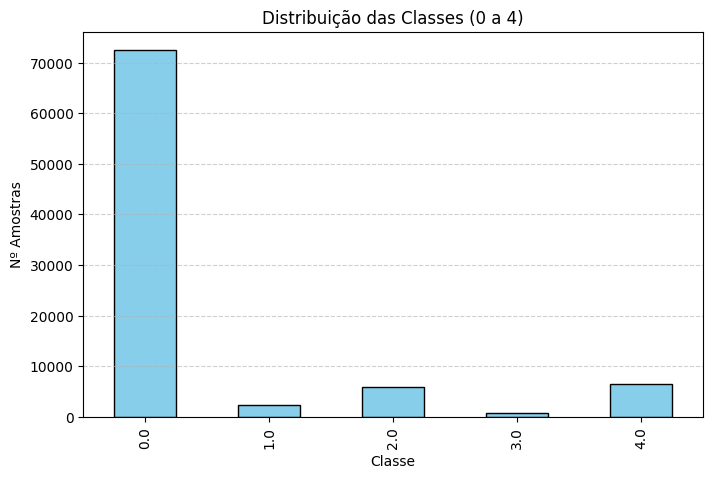

187
0.0    0.827729
4.0    0.073452
2.0    0.066108
1.0    0.025390
3.0    0.007321
Name: proportion, dtype: float64


In [5]:
#Distribuição das classes
plt.figure(figsize=(8,5))
#df_train[187] pois é a ultima coluna do dataset que é o target
train_df[187].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribuição das Classes (0 a 4)")
plt.xlabel("Classe")
plt.ylabel("Nº Amostras")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Percentagem de cada classe
print(train_df[187].value_counts(normalize=True))

#como conseguimos ver, está muito desbalanceado. No entanto só devemos resolver este problema depois 
#de dividir o dataset em test e train, para deixar o test o mais real possível

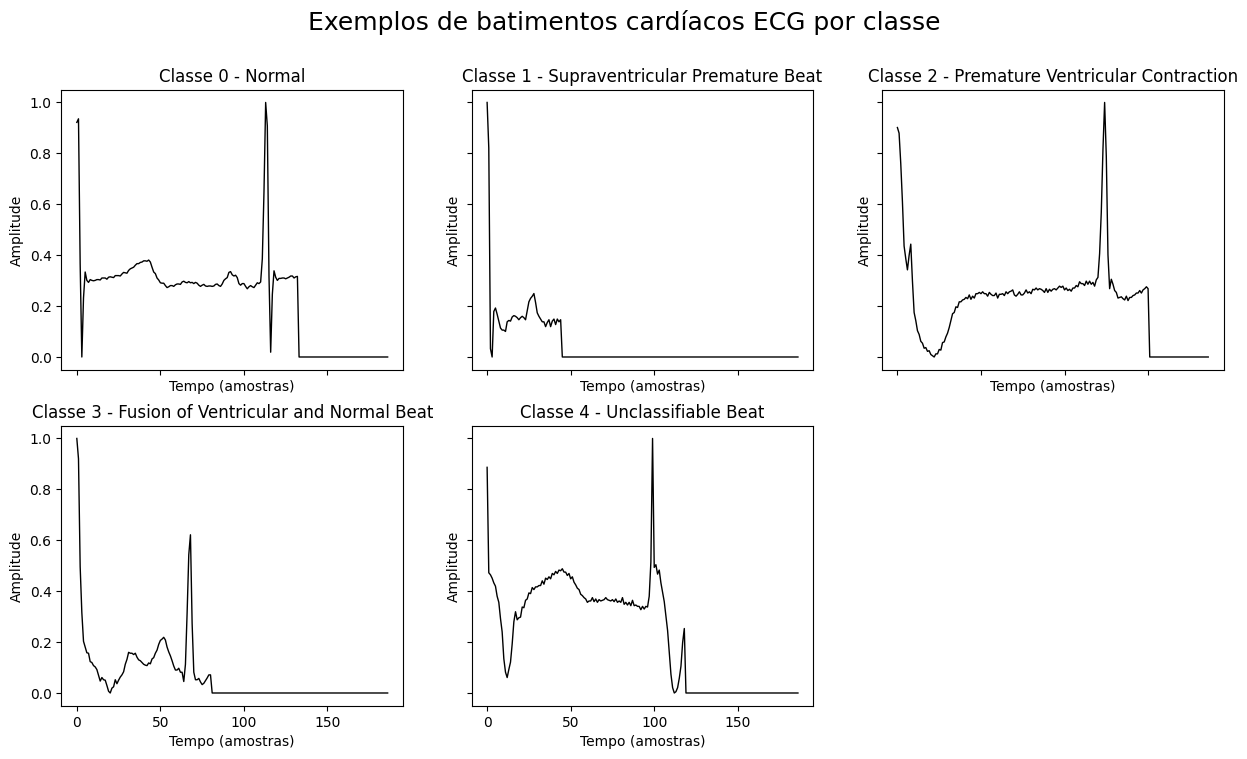

In [6]:
#para verificarmos que tipos de dados estamos a lidar:

#definir variáveis auxiliares
label_col = 187
class_mapping = {
    0: "Normal",
    1: "Supraventricular Premature Beat",
    2: "Premature Ventricular Contraction",
    3: "Fusion of Ventricular and Normal Beat",
    4: "Unclassifiable Beat"
}
#para escolher uma amostra aleatória da classe
RANDOM_SEED = 42

#subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

labels = sorted(train_df[label_col].unique())

for i, label in enumerate(labels):
    if i >= len(axes):
        break
    #selecionar um exemplo aleatório dessa classe
    sample_signal = train_df[train_df[label_col] == label].sample(n=1).iloc[0, :-1]
    
    axes[i].plot(sample_signal, color='black', linewidth=1)
    axes[i].set_title(f'Classe {int(label)} - {class_mapping[label]}')
    axes[i].set_xlabel('Tempo (amostras)')
    axes[i].set_ylabel('Amplitude')

#apenas para retirar o ultimo subplot que está vazio
if len(labels) < len(axes):
    for j in range(len(labels), len(axes)):
        fig.delaxes(axes[j])
        
fig.suptitle('Exemplos de batimentos cardíacos ECG por classe', fontsize=18)
plt.show()

In [7]:
#Como podemos observar nos gráficos, o final está coberto de 0's
#Também é possível reparar que devido à forma como os batimentos foram recortados, a escala temporal não está correta, assim qualuqer dado temporal torna-se inutilizável para as features
#Mais à frente vamos obter features na escala das frequências a partir do TSFEL, assim, será necessário retirar os 0's para n corromper os dados
def remove_padding(X):
    #procura o valor mais elevado no index que não é 0
    last_n = np.max(np.nonzero(X))
    return X[:last_n+1]
#esta função só poderá ser usada no código do TSFEL pora evitar trabalhar com Nan's

In [8]:
#Mais um problema que nos deparámos é que existem sinais que têm bem mais zeros do que sinal, ou seja, foram mal divididos e portanto funcionam como ruído para o nosso modelo
#Assim, vamos remove-los:
from tqdm import tqdm
def data_filter (DF):   
    drops=[]
    for i in tqdm(range(len(DF)), desc="Filtrando a data"):
        counts = (DF.iloc[i, :-1] == 0).value_counts()
        true = float(counts.get(True, 0))
        false = float(counts.get(False, 0))
        ratio = true/(true+false)
        ratio
        if ratio > 0.80:
            drops.append(i)
    if len(drops) != 0:       
        df=DF.drop(drops)
    return df

In [9]:
train_df_filtered = data_filter(train_df)
test_df_filtered = data_filter(test_df)

Filtrando a data: 100%|██████████| 21892/21892 [00:02<00:00, 8755.33it/s]


In [10]:
print(train_df_filtered.shape)
print(test_df_filtered.shape)

(87269, 188)
(21798, 188)


In [11]:
# Separar features e target
X_train = train_df_filtered.iloc[:, :-1]
labels_train = train_df_filtered.iloc[:, -1] #por agora vai ser label porque se irá concatenar tudo mais à frente

X_test = test_df_filtered.iloc[:, :-1]
labels_test = test_df_filtered.iloc[:, -1]

print("Dimensões X_train:", X_train.shape)
print("Dimensões y_train:", labels_train.shape)
print("Dimensões X_test:", X_test.shape)
print("Dimensões y_test:", labels_test.shape)

Dimensões X_train: (87269, 187)
Dimensões y_train: (87269,)
Dimensões X_test: (21798, 187)
Dimensões y_test: (21798,)


# Criação de Features

#### The original dataset is a time series, and to capture the physiological characteristics of the heartbeats, features were extracted using the TSFEL library (temporal, statistical, and frequency features) as well as morphological features (R, Q, S, P, T).

Since the 186 values represent only temporal samples of the heartbeat and not a compact description of its physiological characteristics, statistical, temporal, and frequency features were extracted.

In [13]:
import tsfel
import numpy as np
import pandas as pd

cfg = tsfel.get_features_by_domain()

In [14]:
#transforma cada linha num conjunto de +- 70 features


def extract_tsfel_features(X):
    feature_list = []

    # progress bar para iterar pelas janelas
    for i in tqdm(range(len(X)), desc="Extraindo features TSFEL"):
        # extrair a linha i como array NumPy
        signal = X.iloc[i].values
        #retirar os 0's de cada linha
        signal_n0 = remove_padding(signal)

        features = tsfel.time_series_features_extractor(cfg, signal_n0, fs=125, verbose=0)
        feature_list.append(features.iloc[0].values)

    # obter nomes das colunas
    columns = tsfel.time_series_features_extractor(cfg, X.iloc[0].values, fs=125, verbose=0).columns
    return pd.DataFrame(feature_list, columns=columns)

In [15]:
#aplicar ao treino e ao teste
X_train_feats = extract_tsfel_features(X_train)
X_test_feats = extract_tsfel_features(X_test)

print("Nº de features extraídas:", X_train_feats.shape[1])

Extraindo features TSFEL: 100%|██████████| 21798/21798 [03:09<00:00, 115.12it/s]


Nº de features extraídas: 156


In [16]:
#analisar as features 
X_train_feats.describe()
X_train_feats.isna().any(axis=1).sum() #O TSFEL criou Nans

1688

In [17]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#necessário atualizar X_train e X_test para serem os df´s com as features criadas, substituindo as "features" antigas
X_train = X_train_feats.copy()
X_test = X_test_feats.copy()

In [18]:
#As próximas features que se vão criar são as features morfológicas, que dizem respeito apenas a este tipo de sinal
#Calculamos então as intensidades de R Q S P e T
from scipy.signal import find_peaks
def qrstp_features(X):
    qrstp_list=[]
    for i in tqdm(range(len(X)), desc="Extraindo intensidades QRSTP"):
        qrstp_values = []
        
        # extrair a linha i como array NumPy
        signal = X.iloc[i].values
        #retirar os 0's de cada linha
        signal_n0 = remove_padding(signal)
        
        #pico R
        peaks, _ = find_peaks(signal_n0)
        r_peak = peaks[np.argmax(signal_n0[peaks])]# escolhe o pico mais alto
        r_peak_value = float(signal_n0[r_peak]) #valor do pico, geralmente é 1
        qrstp_values.append(r_peak_value)
        
        # Q é o mínimo 20 epochs antes do R (somamos max(r_peak-20,0) para acertar o index)
        q_index = np.argmin(signal_n0[max(r_peak-20,0):r_peak]) + max(r_peak-20,0)
        if q_index==0:
            q_value = 0 #caso q n esteja representado no sinal 
        else:
            q_value = float(signal_n0[q_index])
        qrstp_values.append(q_value)
        
        # S é o mínimo 20 epochs depois do R (somamos r_peak para acertar o index)
        s_index = np.argmin(signal_n0[r_peak:min(r_peak+20,len(signal_n0))]) + r_peak
        if s_index == len(signal_n0):
            s_value = 0
        else:
            s_value = float(signal_n0[s_index])
        qrstp_values.append(s_value)
        
        #P é o máximo 40 epochs antes do R
        p_index = np.argmax(signal_n0[max(r_peak-40,0):r_peak]) + max(r_peak-40,0)
        if p_index==0:
            p_value = 0 #caso q n esteja representado no sinal 
        else:
            p_value = float(signal_n0[p_index])
        qrstp_values.append(p_value)
        
        #T é o máximo 40 epochs depois do R
        t_index = np.argmin(signal_n0[r_peak:min(r_peak+40,len(signal_n0))]) + r_peak
        if t_index == len(signal_n0):
            t_value = 0
        else:
            t_value = float(signal_n0[t_index])
        qrstp_values.append(t_value)
        qrstp_list.append(qrstp_values)
    columns = ["R", "Q", "S", "P", "T"]
    return pd.DataFrame(qrstp_list, columns=columns)

In [19]:
X_train_qrstp = qrstp_features(X_train)
X_test_qrstp = qrstp_features(X_test)
X_train_qrstp.describe()
#Como podemos ver, visto que as intensidades dos sinais já estão normalizadas, estas features já vêm normalizadas

Extraindo intensidades QRSTP: 100%|██████████| 21798/21798 [00:00<00:00, 34549.16it/s]


,R,Q,S,P,T
count,87269.000000,87269.000000,87269.000000,87269.000000,87269.000000
mean,114.237160,-16.998557,-1729.900712,66.217071,-1850.118721
std,25.631293,34.644074,1275.228175,19.836448,1168.326624
min,44.642857,-474.655746,-9053.917668,0.000000,-9053.917668
25%,97.397728,-10.969846,-2347.429650,50.632911,-2360.827064
50%,111.133887,-0.008659,-1486.757627,62.028695,-1518.262693
75%,127.581893,-0.005898,-892.738380,81.099270,-1036.153082
max,275.217419,0.759406,0.025641,182.641247,0.019231


In [20]:
#Aplicado o o scaler, será necessário agora juntar os dois dataframes para se obter todas as features em apenas um dataframe
X_train_all_ns = pd.concat([X_train_feats, X_train_qrstp], axis=1)
X_test_all_ns = pd.concat([X_test_feats, X_test_qrstp], axis=1)

#### After feature extraction, the data were normalized using the StandardScaler to ensure that all features contribute equally to the model. Samples containing NaN values were also removed.

New issue:
The data are no longer normalized, because TSFEL creates new features in a new DataFrame, so the previous normalization is lost.

In [21]:
#Normalizar antes de reduzir dimensionalidade

scaler = StandardScaler()
X_train_all_scaled = pd.DataFrame(scaler.fit_transform(X_train_all_ns))
X_test_all_scaled = pd.DataFrame(scaler.transform(X_test_all_ns))

In [22]:
#Acreditamos que o scaler possa ter gerado Nans
print(X_train_all_scaled.isna().any(axis=1).sum())
print(X_test_all_scaled.isna().any(axis=1).sum())

1688
418


In [23]:
#Para aplicar o SMOTE vamos ter de retirar estes casos:

df_train_total = pd.concat([X_train_all_scaled, labels_train], axis=1)
df_test_total = pd.concat([X_test_all_scaled, labels_test], axis=1)
df_train_new = pd.DataFrame(df_train_total.dropna())
df_test_new = pd.DataFrame(df_test_total.dropna())

X_train_all = df_train_new.iloc[:, :-1]
y_train = df_train_new.iloc[:, -1]

X_test_all = df_test_new.iloc[:, :-1]
y_test = df_test_new.iloc[:, -1]


First, we applied only SMOTE, which performed oversampling and resulted in each class having 72,471 samples. However, we realized that we generated synthetic samples disproportionately because some classes had very few samples. Therefore, we implemented a "middle ground" approach: we downsampled class 0 to 10,000 samples and applied SMOTE (oversampling) to the other classes, resulting in all classes having 10,000 samples each.

Após UNDERSAMPLING:
187
0.0    10000
4.0     6069
2.0     5504
1.0     1974
3.0      627
Name: count, dtype: int64

Após SMOTE:
187
0.0    10000
1.0    10000
2.0    10000
3.0    10000
4.0    10000
Name: count, dtype: int64


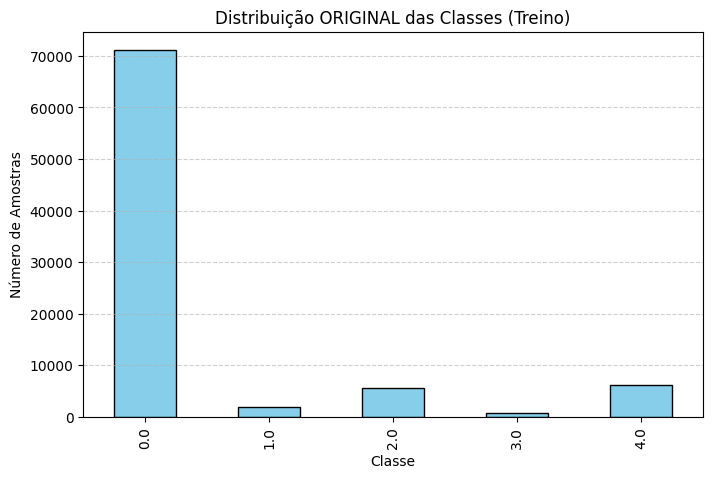

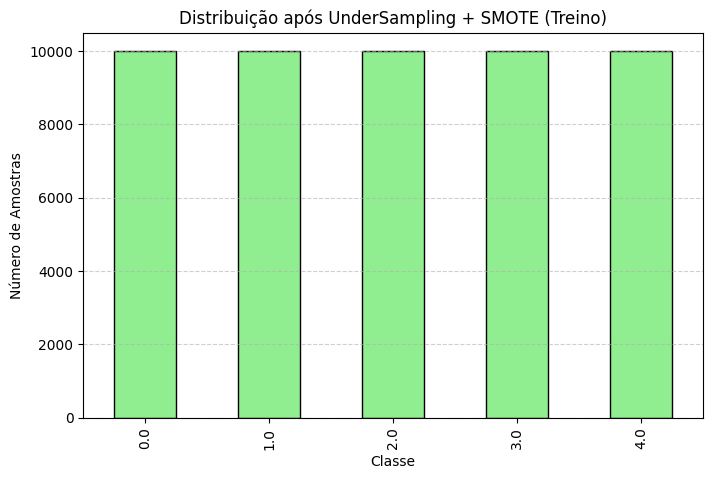

In [24]:
# Under-sample apenas da classe 0 para 10k

rus = RandomUnderSampler(sampling_strategy={0: 10000},random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_all, y_train)

print("Após UNDERSAMPLING:")
print(pd.Series(y_rus).value_counts())

#SMOTE para aumentar as restantes classes para 10k

smote = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000, 4: 10000},random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_rus, y_rus)

print("\nApós SMOTE:")
print(pd.Series(y_train_bal).value_counts())

#PLOTS da distribuição antes e depois
plt.figure(figsize=(8,5))
y_train.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribuição ORIGINAL das Classes (Treino)")
plt.xlabel("Classe")
plt.ylabel("Número de Amostras")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(8,5))
pd.Series(y_train_bal).value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Distribuição após UnderSampling + SMOTE (Treino)")
plt.xlabel("Classe")
plt.ylabel("Número de Amostras")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Feature Selection 

To optimize performance and reduce complexity, two dimensionality reduction techniques were explored:

* Correlation Matrix (Threshold 0.95): Highly correlated features (ρ>0.95) were removed to mitigate multicollinearity.

* PCA (Principal Component Analysis): The number of original features was reduced while retaining 95% of the variance. This resulted in a reduction from 161 features to 28 principal components.

### Correlation Matrix

In [25]:
import seaborn as sns
#Esta função foi baseada na função fornecida pelo Lab 9
def correlate(DF: pd.DataFrame, threshold: float = 0.95, figsize: tuple = (16, 14), cmap=plt.cm.Reds): 
    # Faz a correlação
    matriz_corr = DF.corr(method='pearson')
    
    # Cálculo do valor absoluto
    matriz_corr_absoluta = matriz_corr.abs()
    
    # Apenas seleciona o triângulo superior da matriz de forma a evitar que hajam pares repetidos
    upper_triangle = matriz_corr_absoluta.where(np.triu(np.ones(matriz_corr_absoluta.shape), k=1).astype(bool))
    
    # O treshold irá retirar aquelas com correlação maior do que o indicado pela variável
    corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

    #Retira as features da matriz
    DF_corr = DF.drop(corr_features, axis=1)

    # Plot com o tamanho pedido
    plt.figure(figsize=figsize)
    
    # Heatmap com o código de cores pedido
    sns.heatmap(data=matriz_corr, cmap=cmap, vmin=-1, vmax=1)
    
    # Titulos
    plt.title("Heatmap de correlação ")
    plt.xlabel("Features")
    plt.ylabel("Features")
    
    # Mostra o Plot
    plt.show()
    
    return corr_features, DF_corr

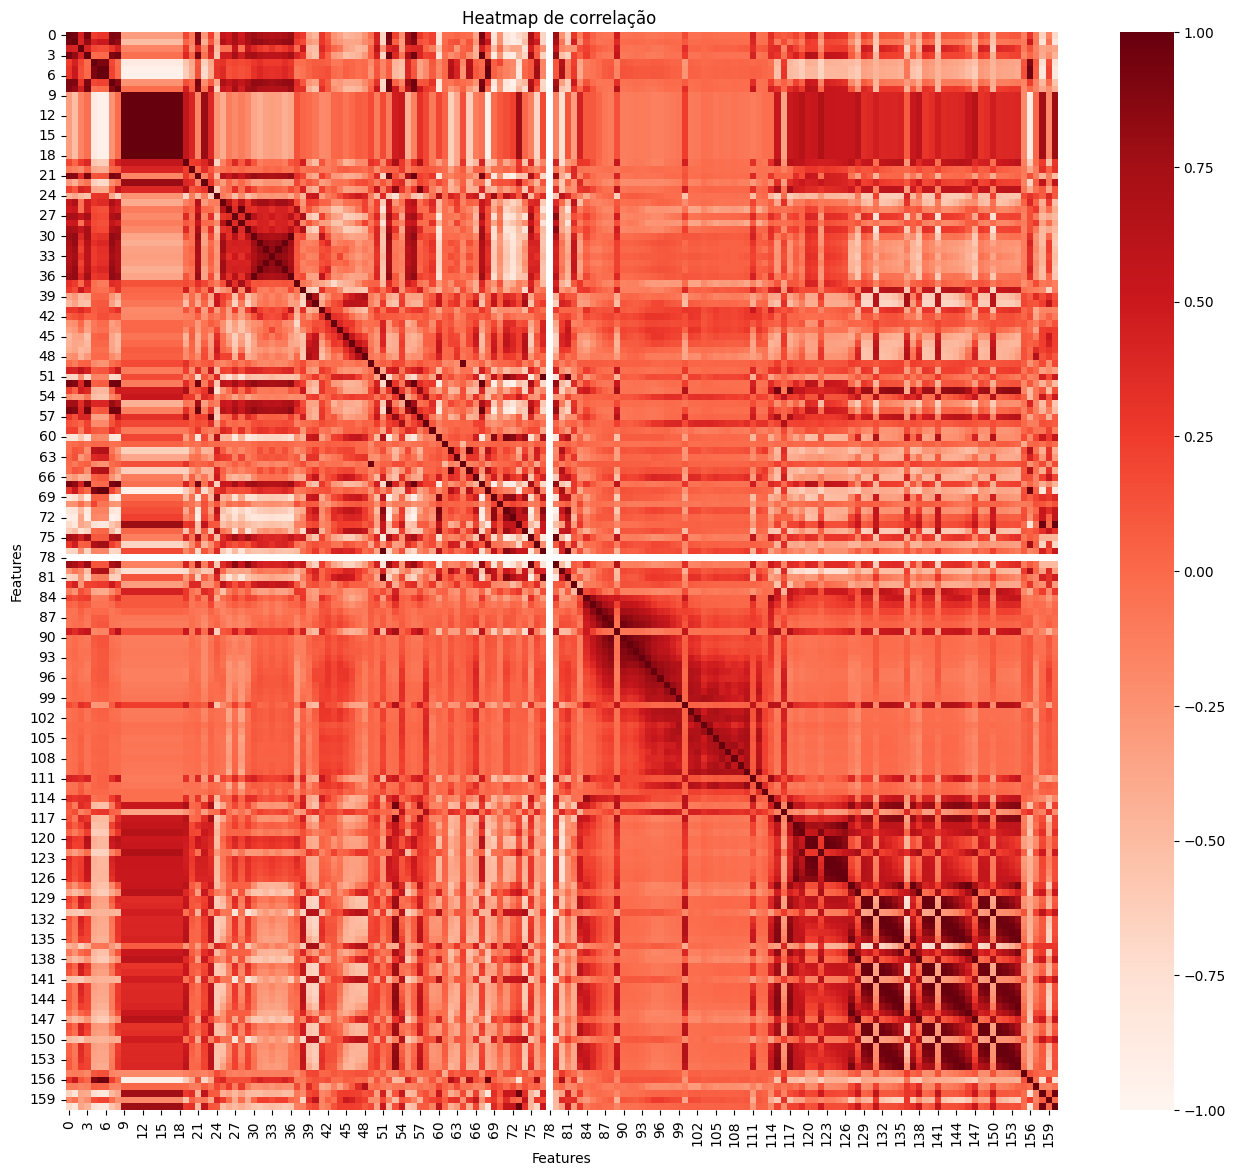

In [26]:
correlation_features, X_train_corr = correlate(X_train_bal) #aqui usamos o dataset depois do SMOTE
X_test_corr = X_test_all.drop(correlation_features, axis=1) #agr restiramos essas mesmas features ao X_test_all

### PCA (Principal Component Analysis)

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # manter 95% da variância
X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca = pca.transform(X_test_all)

print("Componentes usados:", pca.n_components_)

Componentes usados: 28


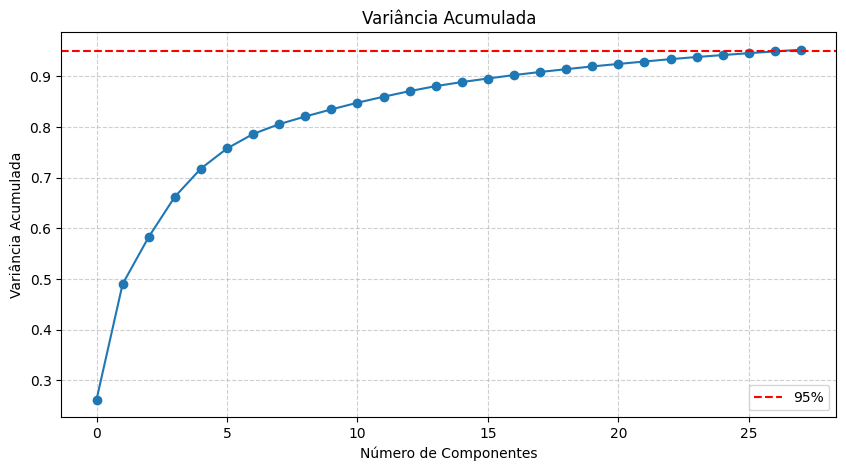

In [28]:
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.title("Variância Acumulada")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Acumulada")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Models

Three classification models were tested and compared (Random Forest, K-Nearest Neighbors, and Support Vector Classifier), applying Cross-Validation (k=10) and Grid Search for hyperparameter optimization.
Performance was evaluated using Accuracy and F1-score.

## Testing with PCA, correlation e with features qrstp

In [29]:
#Para agilizar o processo, iremos utilizar uma função desenvolvida na aula prática do Lab 7 da unidade curricular como base para a função que vamos ultilizar no nosso projeto
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, RocCurveDisplay
from sklearn.metrics import f1_score


def train_and_evaluation(model, X_train, y_train, X_test, y_test):
    
    # Treinar o modelo na training data
    model.fit(X_train, y_train)

    # Prever
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    #y_test_pred_proba = model.predict_proba(X_test)
    
    # Calcular a accuracy e o f1 do treino e do teste
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train, average='macro') #usamos f1_macro pois dá a mesma importancia a todas as 5 classes
    test_f1 = f1_score(y_test, y_pred_test, average = 'macro')
    
    # Cross-Validation e Accuracy scores de todos os testes
    acc_cv = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10)
    f1_cv = cross_val_score(estimator=model, X=X_train, y=y_train, cv=10, scoring ='f1_macro')
    #Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
    #ROC curve
    #y_scores = y_test_pred_proba[:, 1]
    #RocCurveDisplay.from_predictions(y_test, y_scores)
    #AUC = roc_auc_score(y_test, y_scores)
    # Dicionário de métricas
    metrics = {
        'Model': model.__class__.__name__,      # Nome do Modelo utilizado em string
        'Train ACC': train_acc,                 # Training accuracy
        'Test ACC': test_acc,                   # Test accuracy
        'K-fold ACC mean': np.mean(acc_cv),     # Média da accuracy depois do cross-validation
        'K-fold ACC std': np.std(acc_cv),       # Desvio Padrão da accuracy depois do cross-validation
        'Train F1-score': train_f1,             # Training F1 
        'Test F1-score': test_f1,               # Test F1
        'K-fold F1 mean': np.mean(f1_cv),       # Média da accuracy depois do cross-validation
        'K-fold F1 std': np.std(f1_cv),         # Desvio Padrão da accuracy depois do cross-validation
    }
    
    return metrics

In [30]:
# Resultados PCA
X_train_pca
X_test_pca
#Resultados Correlation
X_train_corr
X_test_corr
#Y's
y_train_bal
y_test

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
21793    4.0
21794    4.0
21795    4.0
21796    4.0
21797    4.0
Name: 187, Length: 21289, dtype: float64

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

RandomForest = RandomForestClassifier()
KNN = KNeighborsClassifier()
SVC = SVC()
model_metrics = []

## Correlation

#### Random Forest

Treinar RandomForest: 100%|██████████| 1/1 [14:17<00:00, 857.39s/it]


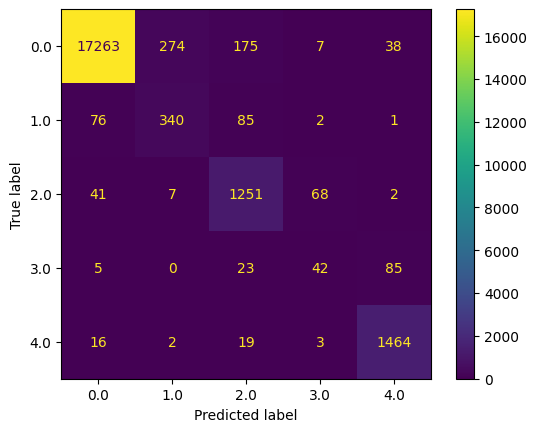

In [34]:
from tqdm import tqdm

for _ in tqdm(range(1), desc="Treinar RandomForest"):
    metrics_rf_corr = train_and_evaluation(RandomForest, X_train_corr, y_train_bal, X_test_corr, y_test)

model_metrics.append(metrics_rf_corr)


#### KNN

In [36]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
        'n_neighbors': range(2,50)
    }
randomsearch = RandomizedSearchCV(estimator=KNN, param_distributions=param_grid, cv=5, scoring='accuracy', verbose=2, n_iter=100, random_state=67, refit=True)
KNN_corr=randomsearch.fit(X_train_corr, y_train_bal).best_estimator_
#Verification step + gráfico parâmetro
metrics_KNN_corr = train_and_evaluation(KNN_corr, X_train_corr, y_train_bal, X_test_corr, y_test)
model_metrics.append(metrics_KNN_corr)

/Users/mirandaaa/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=100. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ......................................n_neighbors=2; total time=  25.1s
[CV] END ......................................n_neighbors=2; total time=  28.2s
[CV] END ......................................n_neighbors=2; total time=  29.2s
[CV] END ......................................n_neighbors=2; total time=  25.4s
[CV] END ......................................n_neighbors=2; total time=  27.3s
[CV] END ......................................n_neighbors=3; total time=  26.0s
[CV] END ......................................n_neighbors=3; total time=  27.9s
[CV] END ......................................n_neighbors=3; total time=  27.8s
[CV] END ......................................n_neighbors=3; total time=  28.4s
[CV] END ......................................n_neighbors=3; total time=  28.9s
[CV] END ......................................n_neighbors=4; total time=  28.7s
[CV] END ......................................


KeyboardInterrupt



In [37]:
model_metrics

[{'Model': 'RandomForestClassifier',
  'Train ACC': 1.0,
  'Test ACC': 0.9566912490018319,
  'K-fold ACC mean': 0.9699000000000002,
  'K-fold ACC std': 0.009644998703991636,
  'Train F1-score': 1.0,
  'Test F1-score': 0.744744077321912,
  'K-fold F1 mean': 0.9695870725720017,
  'K-fold F1 std': 0.009549797503706596},
 {'Model': 'RandomForestClassifier',
  'Train ACC': 1.0,
  'Test ACC': 0.9572079477664521,
  'K-fold ACC mean': 0.9693400000000001,
  'K-fold ACC std': 0.009805733016965147,
  'Train F1-score': 1.0,
  'Test F1-score': 0.7394880845254636,
  'K-fold F1 mean': 0.9695272240057902,
  'K-fold F1 std': 0.009623953858914706},
 {'Model': 'RandomForestClassifier',
  'Train ACC': 1.0,
  'Test ACC': 0.9563624406970737,
  'K-fold ACC mean': 0.9697399999999998,
  'K-fold ACC std': 0.009597937278394785,
  'Train F1-score': 1.0,
  'Test F1-score': 0.7382510980875654,
  'K-fold F1 mean': 0.9698549704083408,
  'K-fold F1 std': 0.009839611823840183}]

#### SVC

In [ ]:
param_grid = {
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    }
randomsearch = RandomizedSearchCV(estimator=SVC, param_distributions=param_grid, cv=5, scoring='accuracy', verbose=2, n_iter=100, random_state=67, refit=True)
SVC_corr=randomsearch.fit(X_train_corr, y_train_bal).best_estimator_
metrics_SVC_corr = train_and_evaluation(SVC_corr, X_train_corr, y_train_bal, X_test_corr, y_test)
model_metrics.append(metrics_SVC_corr)

In [39]:
models_corr_df = pd.DataFrame(model_metrics).set_index('Model')
models_corr_df

,Train ACC,Test ACC,K-fold ACC mean,K-fold ACC std,Train F1-score,Test F1-score,K-fold F1 mean,K-fold F1 std
Model,,,,,,,,
RandomForestClassifier,1.0,0.956691,0.96990,0.009645,1.0,0.744744,0.969587,0.009550
RandomForestClassifier,1.0,0.957208,0.96934,0.009806,1.0,0.739488,0.969527,0.009624
RandomForestClassifier,1.0,0.956362,0.96974,0.009598,1.0,0.738251,0.969855,0.009840


## PCA

In [ ]:
model_metrics_2=[]
metrics_rf_pca = train_and_evaluation(RandomForest, X_train_pca, y_train_bal, X_test_corr, y_test)
model_metrics_2.append(metrics_rf_pca)

C:\Users\guilh\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 98 is smaller than n_iter=100. Running 98 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 98 candidates, totalling 490 fits
[CV] END ......................................n_neighbors=2; total time=   0.3s
[CV] END ......................................n_neighbors=2; total time=   0.3s
[CV] END ......................................n_neighbors=2; total time=   0.3s
[CV] END ......................................n_neighbors=2; total time=   0.3s
[CV] END ......................................n_neighbors=2; total time=   0.3s
[CV] END ......................................n_neighbors=3; total time=   0.3s
[CV] END ......................................n_neighbors=3; total time=   0.3s
[CV] END ......................................n_neighbors=3; total time=   0.3s
[CV] END ......................................n_neighbors=3; total time=   0.3s
[CV] END ......................................n_neighbors=3; total time=   0.3s
[CV] END ......................................n_neighbors=4; total time=   0.2s
[CV] END ......................................

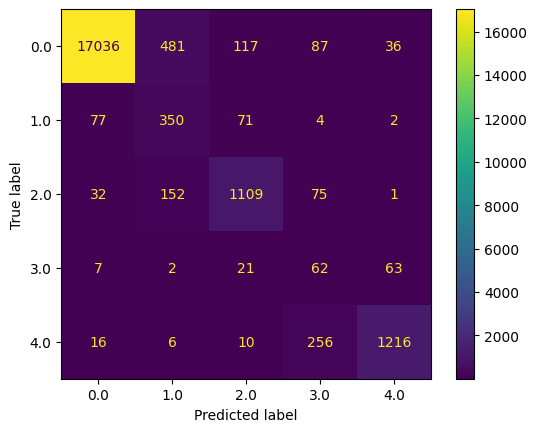

In [66]:
param_grid = {
        'n_neighbors': range(2,100)
    }
randomsearch = RandomizedSearchCV(estimator=KNN, param_distributions=param_grid, cv=5, scoring='accuracy', verbose=2, n_iter=100, random_state=67, refit=True)
KNN_pca=randomsearch.fit(X_train_pca, y_train_bal).best_estimator_
metrics_KNN_pca = train_and_evaluation(KNN_pca, X_train_pca, y_train_bal, X_test_pca, y_test)
model_metrics_2.append(metrics_KNN_pca)

C:\Users\guilh\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=100. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ......................................kernel=linear; total time= 1.2min
[CV] END ......................................kernel=linear; total time= 1.3min
[CV] END ......................................kernel=linear; total time= 1.2min
[CV] END ......................................kernel=linear; total time= 1.2min
[CV] END ......................................kernel=linear; total time= 1.3min
[CV] END ........................................kernel=poly; total time=  20.8s
[CV] END ........................................kernel=poly; total time=  21.0s
[CV] END ........................................kernel=poly; total time=  20.3s
[CV] END ........................................kernel=poly; total time=  20.9s
[CV] END ........................................kernel=poly; total time=  21.1s
[CV] END .........................................kernel=rbf; total time=  28.4s
[CV] END ........................................

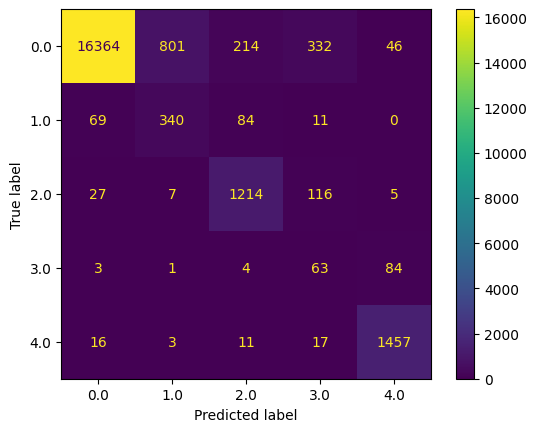

In [67]:
param_grid = {
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
    }
randomsearch = RandomizedSearchCV(estimator=SVC, param_distributions=param_grid, cv=5, scoring='accuracy', verbose=2, n_iter=100, random_state=67, refit=True)
SVC_pca=randomsearch.fit(X_train_pca, y_train_bal).best_estimator_
metrics_SVC_pca = train_and_evaluation(SVC_pca, X_train_pca, y_train_bal, X_test_pca, y_test)
model_metrics_2.append(metrics_SVC_pca)

In [68]:
models_PCA_df = pd.DataFrame(model_metrics).set_index('Model')
models_PCA_df

,Train ACC,Test ACC,K-fold ACC mean,K-fold ACC std,Train F1-score,Test F1-score,K-fold F1 mean,K-fold F1 std
Model,,,,,,,,
RandomForestClassifier,1.0000,0.956785,0.96996,0.010362,1.000000,0.744896,0.969878,0.010100
KNeighborsClassifier,0.9884,0.929071,0.95788,0.018227,0.988378,0.664053,0.957804,0.018293
SVC,0.8598,0.928508,0.85078,0.018097,0.856697,0.687491,0.847317,0.018280


* The best-performing model, both in Test Set Accuracy and K-fold Cross-Validation F1-score, is the RandomForestClassifier.

Random Forest (PCA): Test ACC of 0.9568 and K-fold F1 mean of 0.9699.

Random Forest (Correlation): Test ACC of 0.9572 and K-fold F1 mean of 0.9695.

Performance is similar using PCA (28 features) or Correlation Matrix (103 features), suggesting that dimensionality reduction with PCA is the most efficient strategy, as it achieves comparable performance with significantly fewer features.